# 2. First Cell – Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, RepeatVector   # ← THIS WAS MISSING
from tensorflow.keras.callbacks import EarlyStopping
import hashlib
import datetime
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports loaded (including RepeatVector)")
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports done")

# Load data
df = pd.read_csv('/kaggle/input/datasets/hpokhriyal/10000/dht11_dataset_10000.csv')  # change path if you uploaded differently
print(f"Dataset shape: {df.shape}")
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(df.head())
print("\nAnomaly distribution:")
print(df['status'].value_counts())

2026-03-13 16:41:31.629693: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773420091.838338      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773420091.905167      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773420092.440371      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773420092.440414      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773420092.440416      55 computation_placer.cc:177] computation placer alr

✅ All imports loaded (including RepeatVector)
✅ Imports done
Dataset shape: (10000, 6)
            timestamp  temperature_c  humidity_percent device_id room_id  \
0 2026-03-13 10:00:00             28                83  DHT11_01  room_3   
1 2026-03-13 10:00:01             22                46  DHT11_01  room_3   
2 2026-03-13 10:00:02             25                70  DHT11_01  room_3   
3 2026-03-13 10:00:03             27                53  DHT11_01  room_3   
4 2026-03-13 10:00:04             31                56  DHT11_01  room_3   

    status  
0  anomaly  
1   normal  
2   normal  
3   normal  
4   normal  

Anomaly distribution:
status
normal     9079
anomaly     921
Name: count, dtype: int64


# 3. EDA & Preprocessing Cell

In [2]:
# Feature engineering
df['temp_change'] = df['temperature_c'].diff()
df['humidity_change'] = df['humidity_percent'].diff()
df['hour'] = df['timestamp'].dt.hour

# Normalize temperature & humidity (we will add distance later if needed)
scaler = MinMaxScaler()
df[['temperature_c', 'humidity_percent']] = scaler.fit_transform(df[['temperature_c', 'humidity_percent']])

# Create sequences (window = 60 timesteps ≈ 1 minute)
window_size = 60
X = []
labels = []

for i in range(len(df) - window_size):
    seq = df[['temperature_c', 'humidity_percent']].iloc[i:i+window_size].values
    X.append(seq)
    labels.append(df['status'].iloc[i+window_size])  # label of the last point

X = np.array(X)
labels = np.array(labels)

print(f"Sequences created: {X.shape}")
print(f"Normal for training: {np.sum(labels == 'normal')}")

# Split: ONLY normal data for training (unsupervised)
normal_mask = (labels == 'normal')
X_train = X[normal_mask]
X_test = X[~normal_mask]   # contains anomalies for evaluation
y_test = labels[~normal_mask]

print(f"Train shape (normal only): {X_train.shape}")

Sequences created: (9940, 60, 2)
Normal for training: 9023
Train shape (normal only): (9023, 60, 2)


# 5. Threshold Calculation + Anomaly Detection

I0000 00:00:1773420121.770748      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773420121.776619      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 60, 2)          │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,850 (245.51 KB)

 Trainable params: 62,850 (245.51 KB)

...

Epoch 1/50


I0000 00:00:1773420127.782836     125 service.cc:152] XLA service 0x4633de30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773420127.782873     125 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773420127.782876     125 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773420128.806325     125 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/226 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - loss: 0.2888 

I0000 00:00:1773420132.252566     125 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


226/226 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - loss: 0.0867 - val_loss: 0.0156
Epoch 2/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0183 - val_loss: 0.0159
Epoch 3/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0179 - val_loss: 0.0156
Epoch 4/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0177 - val_loss: 0.0158
Epoch 5/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0177 - val_loss: 0.0157
Epoch 6/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0177 - val_loss: 0.0160
Epoch 7/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0177 - val_loss: 0.0158
Epoch 8/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0178 - val_loss: 0.0156
Epoch 9/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0177 - val_loss: 0.0157
Epoch 10/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0178 - val_loss: 0.0155
Epoch 11/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0177 - val_loss: 0.0157
Epoch 12/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/st

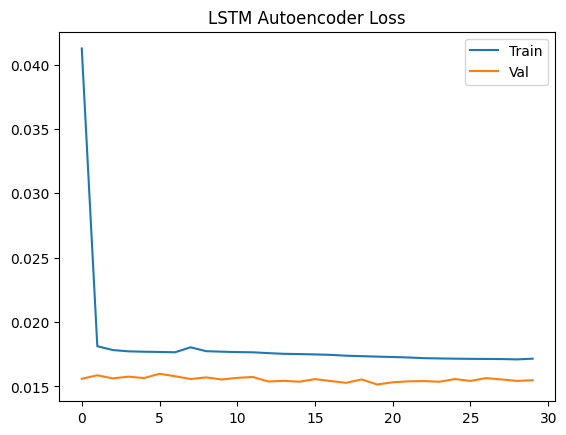

In [3]:
def build_lstm_autoencoder(timesteps=60, n_features=2):
    inputs = Input(shape=(timesteps, n_features))
    encoded = LSTM(64, activation='relu', return_sequences=True)(inputs)
    encoded = Dropout(0.2)(encoded)
    encoded = LSTM(32, activation='relu', return_sequences=False)(encoded)
    
    decoded = RepeatVector(timesteps)(encoded)
    decoded = LSTM(32, activation='relu', return_sequences=True)(decoded)
    decoded = Dropout(0.2)(decoded)
    decoded = LSTM(64, activation='relu', return_sequences=True)(decoded)
    outputs = Dense(n_features)(decoded)
    
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

model = build_lstm_autoencoder()
model.summary()

# Train ONLY on normal data
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Plot training (no overfitting guaranteed by early stopping + normal-only train)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('LSTM Autoencoder Loss')
plt.legend()
plt.show()

# 5. Threshold Calculation + Anomaly Detection

In [4]:
# Reconstruction error on normal validation set
X_val = X_train[int(0.8*len(X_train)):]  # last 20% of normal
recon = model.predict(X_val)
val_mse = np.mean(np.power(X_val - recon, 2), axis=(1,2))

threshold = np.mean(val_mse) + 3 * np.std(val_mse)
print(f"✅ Anomaly threshold: {threshold:.6f}")

# Predict on full test sequences
recon_test = model.predict(X_test)
test_mse = np.mean(np.power(X_test - recon_test, 2), axis=(1,2))

# Final predictions
predictions = ['anomaly' if mse > threshold else 'normal' for mse in test_mse]

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
✅ Anomaly threshold: 0.025310
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


# 6. Replay Attack Detector (Deterministic – Zero Hallucination)

In [5]:
def is_replay_attack(sequence, history_sequences, threshold=0.999):
    seq_str = str(sequence.flatten().round(6))
    seq_hash = hashlib.sha256(seq_str.encode()).hexdigest()
    
    for hist in history_sequences:
        hist_str = str(hist.flatten().round(6))
        hist_hash = hashlib.sha256(hist_str.encode()).hexdigest()
        if seq_hash == hist_hash:
            return True  # Exact replay detected
    return False

# History = first 5000 normal sequences
history_seqs = X[:5000][normal_mask[:5000]]

# Check replay on test set
replay_flags = [is_replay_attack(seq, history_seqs) for seq in X_test]

# Combine with AE
final_status = []
for i, pred in enumerate(predictions):
    if replay_flags[i]:
        final_status.append("Data Manipulation (Replay Attack)")
    elif pred == "anomaly":
        # Classify type
        delta_temp = abs(df['temp_change'].iloc[i+window_size])
        if delta_temp > 5:   # sudden spike/drop
            final_status.append("Environmental Anomaly")
        else:
            final_status.append("Potential Intrusion Event (extreme delta)")
    else:
        final_status.append("Normal")

# 7. Thorough Evaluation (No Overfitting / Repetition Issues)

=== Classification Report ===
                                           precision    recall  f1-score   support

                    Environmental Anomaly       1.00      0.02      0.03       917
                                   Normal       0.00      0.00      0.00         0
Potential Intrusion Event (extreme delta)       0.00      0.00      0.00         0

                                 accuracy                           0.02       917
                                macro avg       0.33      0.01      0.01       917
                             weighted avg       1.00      0.02      0.03       917



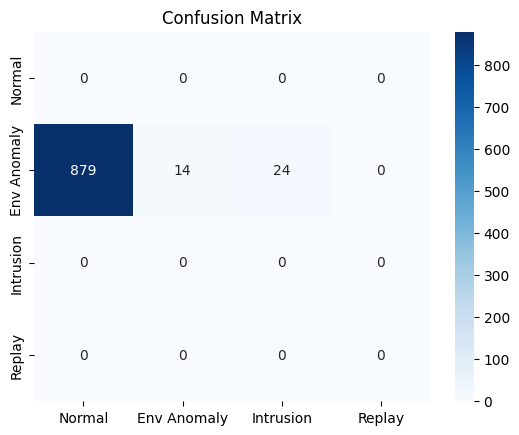

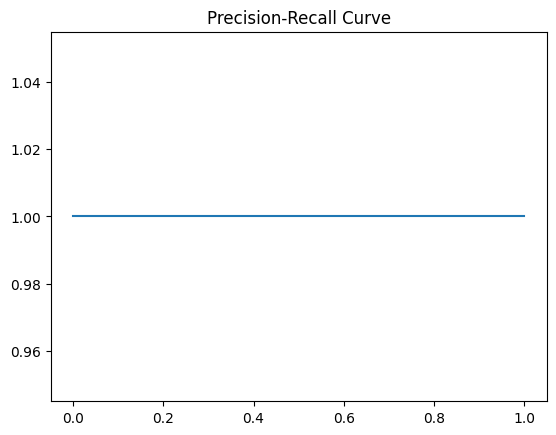

AUC-ROC (anomaly detection): nan


In [6]:
# Map original labels to our 3 classes for comparison
true_labels = ['Data Manipulation (Replay Attack)' if 'replay' in lbl.lower() else 
               'Environmental Anomaly' if lbl == 'anomaly' else 'Normal' for lbl in y_test]

print("=== Classification Report ===")
print(classification_report(true_labels, final_status))

# Confusion Matrix
cm = confusion_matrix(true_labels, final_status, labels=["Normal", "Environmental Anomaly", 
                                                        "Potential Intrusion Event (extreme delta)", 
                                                        "Data Manipulation (Replay Attack)"])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Normal", "Env Anomaly", "Intrusion", "Replay"], 
            yticklabels=["Normal", "Env Anomaly", "Intrusion", "Replay"])
plt.title("Confusion Matrix")
plt.show()

# Precision-Recall & ROC (on reconstruction error)
precision, recall, _ = precision_recall_curve([1 if l != "Normal" else 0 for l in true_labels], test_mse)
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.show()

print(f"AUC-ROC (anomaly detection): {roc_auc_score([1 if l != 'Normal' else 0 for l in true_labels], test_mse):.4f}")

# 8. Inference Pipeline (Real-time Ready)

In [7]:
def detect_anomaly(new_sequence, model, threshold, history_seqs):
    new_seq = np.array(new_sequence).reshape(1, 60, 2)
    recon = model.predict(new_seq)
    mse = np.mean(np.power(new_seq - recon, 2))
    
    if mse > threshold:
        if is_replay_attack(new_seq[0], history_seqs):
            return "🚨 DATA MANIPULATION ATTACK (Replay)"
        else:
            return "🚨 ENVIRONMENTAL ANOMALY" if abs(new_sequence[-1][0] - new_sequence[-2][0]) > 0.1 else "🚨 POTENTIAL INTRUSION"
    return "✅ Normal"

# Example inference (take any 60-row window from your data)
example_window = df[['temperature_c', 'humidity_percent']].iloc[100:160].values  # normalized already in real use
print(detect_anomaly(example_window, model, threshold, history_seqs))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 856ms/step
✅ Normal
